# Pergunta de Pesquisa 2

## Como o consumo de energia elétrica evoluiu ao longo do tempo em Santa Catarina?

---

## Objetivo

Investigar a evolução temporal do consumo de energia elétrica no estado de Santa Catarina utilizando a série histórica disponibilizada pela CELESC.

Esta etapa busca identificar tendências de crescimento, possíveis sazonalidades e mudanças no comportamento do consumo ao longo do período analisado, construindo uma visão histórica da demanda energética estadual.

---

## Motivação

Após identificar como o consumo de energia está distribuído entre os municípios catarinenses na primeira pergunta de pesquisa, o próximo passo é compreender como esse consumo evoluiu ao longo do tempo.

A dimensão temporal complementa a análise espacial realizada anteriormente e permite investigar se o crescimento da demanda ocorreu de forma contínua, acelerada ou em períodos específicos. Essa compreensão será fundamental para as próximas etapas do projeto, que buscarão relacionar infraestrutura energética, desenvolvimento econômico, economia digital, inteligência artificial e, futuramente, possíveis indicadores associados à instalação de Data Centers.

---

## Estratégia de Análise

Para responder a esta pergunta serão realizadas análises da série histórica de consumo de energia elétrica, buscando identificar:

- evolução do consumo ao longo dos anos;
- tendências de crescimento;
- possíveis padrões sazonais;
- períodos de maior ou menor consumo;
- primeiras evidências de mudanças estruturais na demanda energética.

---

## Pergunta de Pesquisa

> **Como o consumo de energia elétrica evoluiu ao longo do tempo em Santa Catarina?**

---

*Esta análise dá continuidade à Pergunta de Pesquisa 1, que investigou a distribuição espacial do consumo de energia entre os municípios catarinenses. Nesta etapa, o foco passa a ser a dimensão temporal do consumo, ampliando a compreensão sobre o comportamento da demanda energética no estado.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Caminho da base
arquivo = "../data/raw/Municipio_Mensal_1T_2026.xlsx"

In [ ]:
# Leitura da planilha de consumo
df = pd.read_excel(arquivo, sheet_name="Consumo MWh")

In [ ]:
# Visualização inicial
df.head()

,tipo,cod_muni,agência,núcleo,unidade,município,cod_classe,classe,1994-01-01 00:00:00,1994-02-01 00:00:00,...,2025-06-01 00:00:00,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00
0,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,1,Residencial,21357.147,20782.785,...,52878.556648,60441.735810,54284.838228,58371.440918,53787.994558,53800.328053,56821.529842,87456.494352,86524.998202,83895.217345
1,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,2,Industrial,1698.383,1641.103,...,2558.042630,2877.644839,2557.793542,2761.337071,2972.536314,2669.177959,2677.598859,3332.905398,3222.091413,3746.075399
2,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,3,Comercial,14766.175,13420.879,...,24422.064633,22060.793725,23029.908608,23087.512572,22567.306346,22916.987372,24222.198117,30172.991984,32276.237126,35388.860964
3,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,4,Rural,25.908,23.863,...,37.052000,43.193000,29.520000,37.073000,37.665,38.949800,43.244000,50.350000,33.971450,42.984200
4,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,5,Poder Público,6393.112,4903.650,...,6667.282925,7209.118309,6673.288946,6409.265993,6528.080709,7015.699795,6543.715033,7558.026813,8207.902689,8857.708610


In [ ]:
# Colunas de identificação
id_vars = [
    "tipo",
    "cod_muni",
    "agência",
    "núcleo",
    "unidade",
    "município",
    "cod_classe",
    "classe",
]

In [ ]:
# Transformação para formato longo
df_long = df.melt(id_vars=id_vars, var_name="data", value_name="consumo_mwh")

In [ ]:
df_long.head()

,tipo,cod_muni,agência,núcleo,unidade,município,cod_classe,classe,data,consumo_mwh
0,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,1,Residencial,1994-01-01 00:00:00,21357.147
1,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,2,Industrial,1994-01-01 00:00:00,1698.383
2,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,3,Comercial,1994-01-01 00:00:00,14766.175
3,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,4,Rural,1994-01-01 00:00:00,25.908
4,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,5,Poder Público,1994-01-01 00:00:00,6393.112


In [ ]:
# Converter para número
df_long["consumo_mwh"] = pd.to_numeric(df_long["consumo_mwh"], errors="coerce")

In [ ]:
# Remover valores inválidos
df_long = df_long.dropna(subset=["consumo_mwh"])

In [ ]:
serie_temporal = df_long.groupby("data")["consumo_mwh"].sum().sort_index()

serie_temporal.head()

data
1994-01-01    647663.042
1994-02-01    665262.084
1994-03-01    692978.778
1994-04-01    681789.502
1994-05-01    657345.323
Name: consumo_mwh, dtype: float64

In [ ]:
serie_temporal.info()

<class 'pandas.Series'>
DatetimeIndex: 387 entries, 1994-01-01 to 2026-03-01
Series name: consumo_mwh
Non-Null Count  Dtype  
--------------  -----  
387 non-null    float64
dtypes: float64(1)
memory usage: 6.0 KB


In [ ]:
serie_temporal.describe()

count    3.870000e+02
mean     1.588697e+06
std      5.722724e+05
min      6.476630e+05
25%      1.084022e+06
50%      1.575933e+06
75%      2.025486e+06
max      2.987765e+06
Name: consumo_mwh, dtype: float64

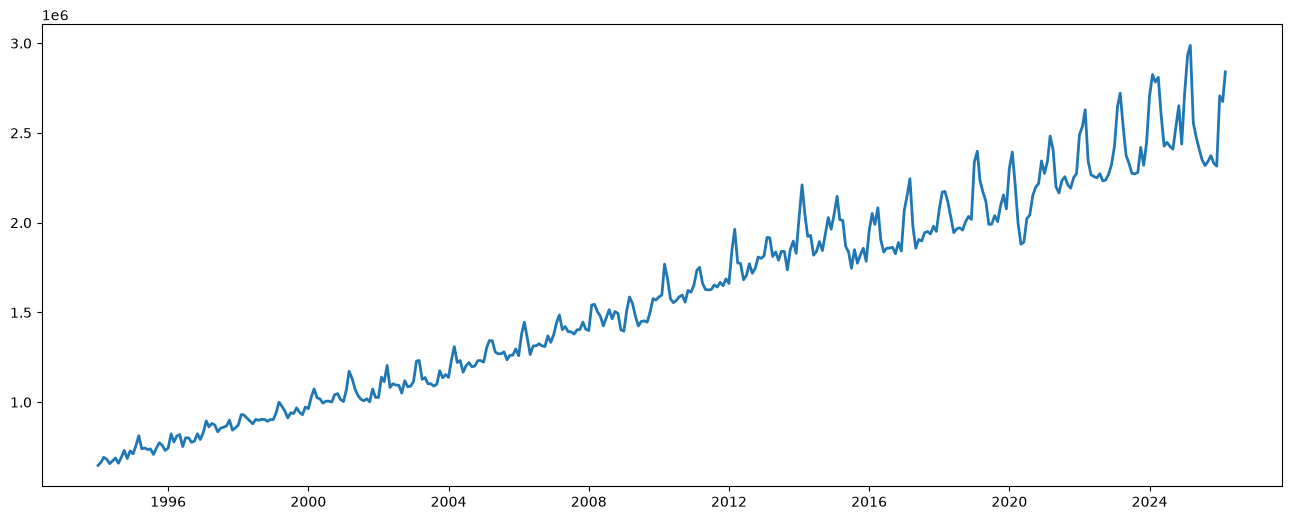

In [ ]:
plt.figure(figsize=(16, 6))

plt.plot(serie_temporal.index, serie_temporal.values, linewidth=2)

### Primeiras observações

A série histórica evidencia uma tendência consistente de crescimento do consumo de energia elétrica em Santa Catarina ao longo do período analisado, compreendido entre janeiro de 1994 e março de 2026.

Observa-se que o consumo mensal evolui de aproximadamente **650 mil MWh** no início da série para valores próximos de **3 milhões de MWh** no período mais recente, indicando um aumento expressivo da demanda energética estadual.

Além da tendência de crescimento, o gráfico apresenta oscilações recorrentes ao longo da série temporal, sugerindo a existência de padrões sazonais no consumo de energia elétrica.

Visualmente, também é possível observar que a amplitude dessas oscilações parece aumentar nos anos mais recentes, indicando que, à medida que o consumo total cresce, as variações mensais tornam-se mais intensas.

Embora o gráfico evidencie um crescimento contínuo da demanda, ele também levanta novas questões de pesquisa. Em particular, torna-se relevante investigar se esse crescimento ocorreu de forma gradual ao longo de todo o período ou se houve fases de aceleração, bem como caracterizar quantitativamente os padrões sazonais observados.

Assim, esta primeira visualização responde à pergunta inicial ao demonstrar que o consumo de energia elétrica em Santa Catarina apresentou crescimento significativo ao longo das últimas décadas, ao mesmo tempo em que evidencia novos aspectos que serão aprofundados nas próximas etapas desta investigação.

In [ ]:
consumo_anual = serie_temporal.resample("YE").sum()

consumo_anual.head()

data
1994-12-31    8.205446e+06
1995-12-31    8.962799e+06
1996-12-31    9.505404e+06
1997-12-31    1.036232e+07
1998-12-31    1.082536e+07
Freq: YE-DEC, Name: consumo_mwh, dtype: float64

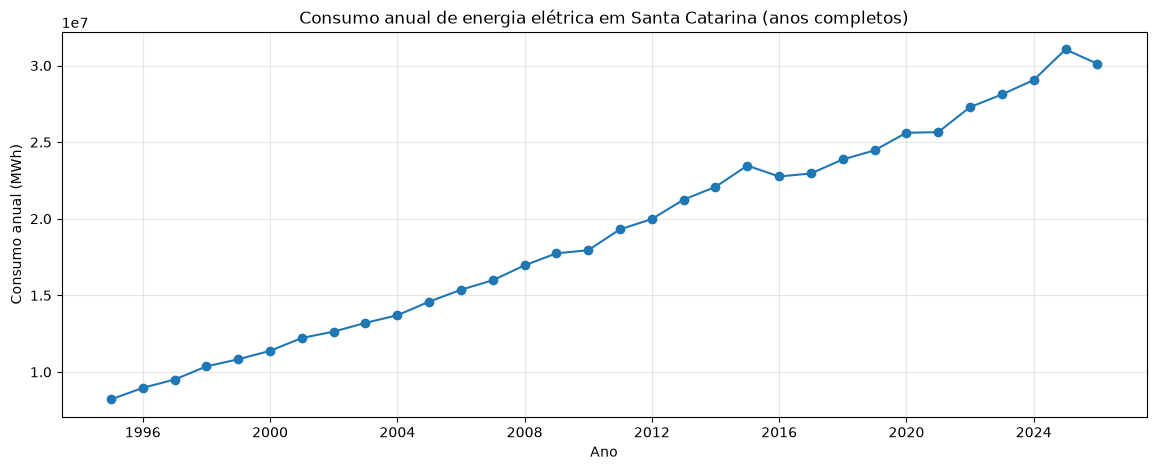

In [ ]:
# Remover o último ano (incompleto)
consumo_anual_completo = consumo_anual.iloc[:-1]

plt.figure(figsize=(14, 5))

plt.plot(consumo_anual_completo.index, consumo_anual_completo.values, marker="o")

plt.title("Consumo anual de energia elétrica em Santa Catarina (anos completos)")
plt.xlabel("Ano")
plt.ylabel("Consumo anual (MWh)")

plt.grid(alpha=0.3)

plt.show()

### Evolução anual do consumo

Ao analisar o consumo anual de energia elétrica, observa-se uma tendência consistente de crescimento ao longo de praticamente todo o período analisado.

A agregação anual reduz o efeito das oscilações mensais observadas na série temporal, permitindo visualizar com maior clareza o aumento da demanda energética no estado.

Não são observadas quedas prolongadas no consumo anual. Embora existam pequenas variações entre anos consecutivos, a tendência predominante é de crescimento contínuo.

O valor referente a 2026 foi desconsiderado nesta análise por representar um ano incompleto na base de dados, contendo apenas informações até o primeiro trimestre.

In [ ]:
# Converter a coluna para datetime
df_long["data"] = pd.to_datetime(df_long["data"])

In [ ]:
df_long.info()

<class 'pandas.DataFrame'>
Index: 1738083 entries, 0 to 2986091
Data columns (total 10 columns):
 #   Column       Dtype         
---  ------       -----         
 0   tipo         str           
 1   cod_muni     int64         
 2   agência      str           
 3   núcleo       str           
 4   unidade      str           
 5   município    str           
 6   cod_classe   int64         
 7   classe       str           
 8   data         datetime64[us]
 9   consumo_mwh  float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 145.9 MB


In [ ]:
# Extrair o mês
df_long["mes"] = df_long["data"].dt.month

consumo_mensal = df_long.groupby("mes")["consumo_mwh"].mean()

consumo_mensal

mes
1     358.386820
2     378.003249
3     381.753622
4     363.591872
5     348.905664
6     339.532977
7     341.655475
8     343.701045
9     340.522268
10    347.275871
11    351.345156
12    347.771165
Name: consumo_mwh, dtype: float64

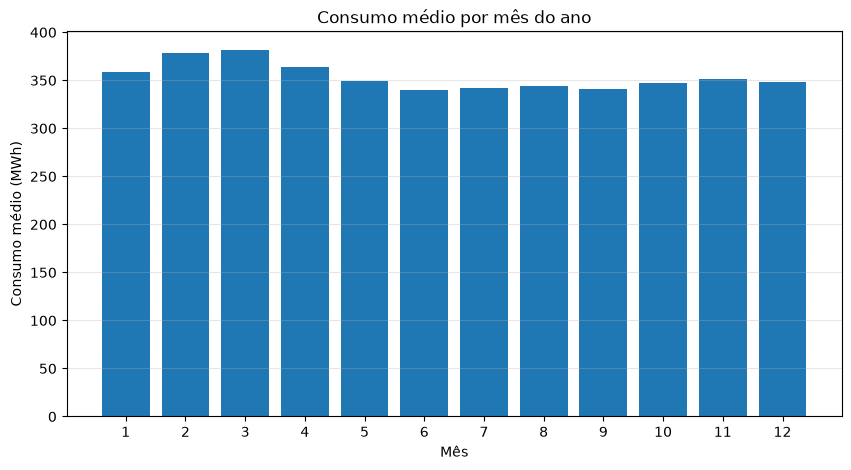

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(consumo_mensal.index, consumo_mensal.values)

plt.title("Consumo médio por mês do ano")
plt.xlabel("Mês")
plt.ylabel("Consumo médio (MWh)")

plt.xticks(range(1, 13))
plt.grid(axis="y", alpha=0.3)

plt.show()

### Sazonalidade do consumo

A análise do consumo médio por mês revela que o consumo de energia elétrica apresenta um comportamento sazonal ao longo do ano.

Os maiores consumos médios concentram-se nos meses de fevereiro e março, enquanto os menores valores são observados entre junho e setembro.

Embora as diferenças entre os meses não sejam muito acentuadas, o padrão se repete ao longo da série histórica, indicando que parte das oscilações observadas no consumo mensal segue um comportamento recorrente.

Essa evidência complementa a análise da série temporal ao mostrar que, além da tendência de crescimento da demanda energética, existe também um componente sazonal que influencia o consumo ao longo do ano.

In [ ]:
# Taxa de crescimento anual (%)
crescimento_anual = consumo_anual_completo.pct_change() * 100

crescimento_anual

data
1994-12-31         NaN
1995-12-31    9.229879
1996-12-31    6.053970
1997-12-31    9.015011
1998-12-31    4.468550
1999-12-31    5.101028
2000-12-31    7.389972
2001-12-31    3.395987
2002-12-31    4.511000
2003-12-31    3.753949
2004-12-31    6.493589
2005-12-31    5.315125
2006-12-31    4.046953
2007-12-31    6.077053
2008-12-31    4.641874
2009-12-31    1.131395
2010-12-31    7.620309
2011-12-31    3.445241
2012-12-31    6.374345
2013-12-31    3.904492
2014-12-31    6.278382
2015-12-31   -3.015503
2016-12-31    0.867604
2017-12-31    3.980917
2018-12-31    2.479605
2019-12-31    4.699288
2020-12-31    0.162562
2021-12-31    6.366200
2022-12-31    3.023293
2023-12-31    3.341092
2024-12-31    6.885844
2025-12-31   -3.002715
Freq: YE-DEC, Name: consumo_mwh, dtype: float64

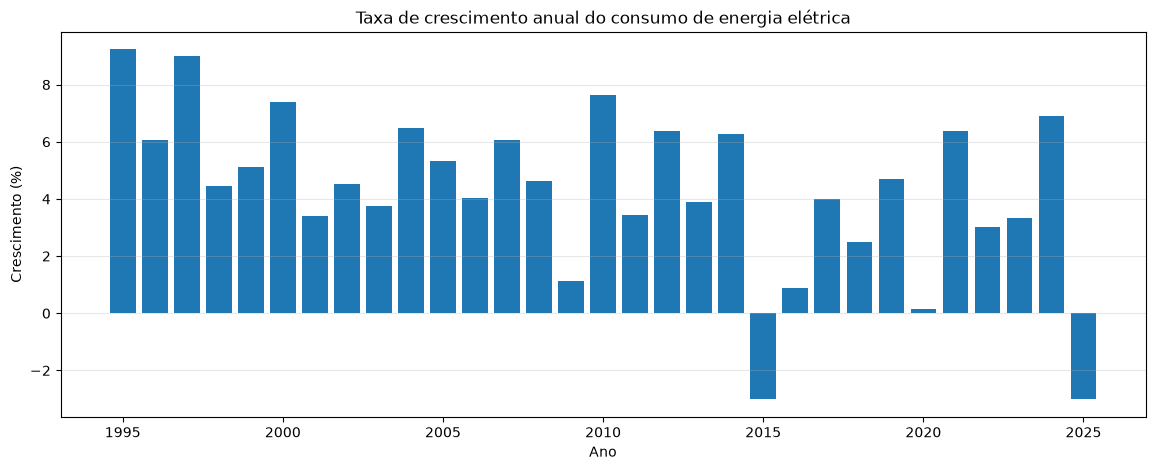

In [ ]:
plt.figure(figsize=(14, 5))

plt.bar(crescimento_anual.index.year, crescimento_anual.values)

plt.title("Taxa de crescimento anual do consumo de energia elétrica")
plt.xlabel("Ano")
plt.ylabel("Crescimento (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Taxa de crescimento anual

A análise da taxa de crescimento anual mostra que o consumo de energia elétrica em Santa Catarina apresentou crescimento positivo na maior parte do período analisado.

Entre meados da década de 1990 e 2014, observa-se um crescimento relativamente consistente, com variações na intensidade do aumento entre os anos.

A série também evidencia alguns períodos de retração, destacando-se 2015 e 2025, nos quais o consumo anual apresentou redução em relação ao ano anterior. Embora esses episódios sejam pontuais, eles indicam que o crescimento da demanda energética não ocorreu de forma uniforme ao longo de toda a série histórica.

De maneira geral, os resultados reforçam que o comportamento temporal do consumo combina uma tendência de crescimento de longo prazo com oscilações anuais de diferentes magnitudes.

# Conclusão da Pergunta de Pesquisa 2

A análise temporal do consumo de energia elétrica em Santa Catarina evidenciou uma trajetória consistente de crescimento ao longo da série histórica compreendida entre 1994 e 2026.

A evolução mensal mostrou uma tendência de aumento da demanda energética acompanhada por oscilações recorrentes. A análise anual confirmou que esse crescimento ocorreu de forma predominante ao longo do período, embora tenham sido identificados anos específicos com retração do consumo.

Também foi possível identificar um padrão sazonal, indicando que determinados meses apresentam, de forma recorrente, maiores níveis de consumo que outros.

Esses resultados ampliam a compreensão sobre o comportamento temporal da demanda energética no estado e complementam a Pergunta de Pesquisa 1, que investigou sua distribuição espacial entre os municípios catarinenses.

Como continuidade desta pesquisa, a próxima etapa buscará aprofundar a análise regional do consumo, investigando diferenças entre as regiões de Santa Catarina e identificando possíveis padrões associados às características econômicas e produtivas do estado.